<a href="https://colab.research.google.com/github/hadeelabbadi/JoVision-AI-Tasks/blob/main/Task6_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

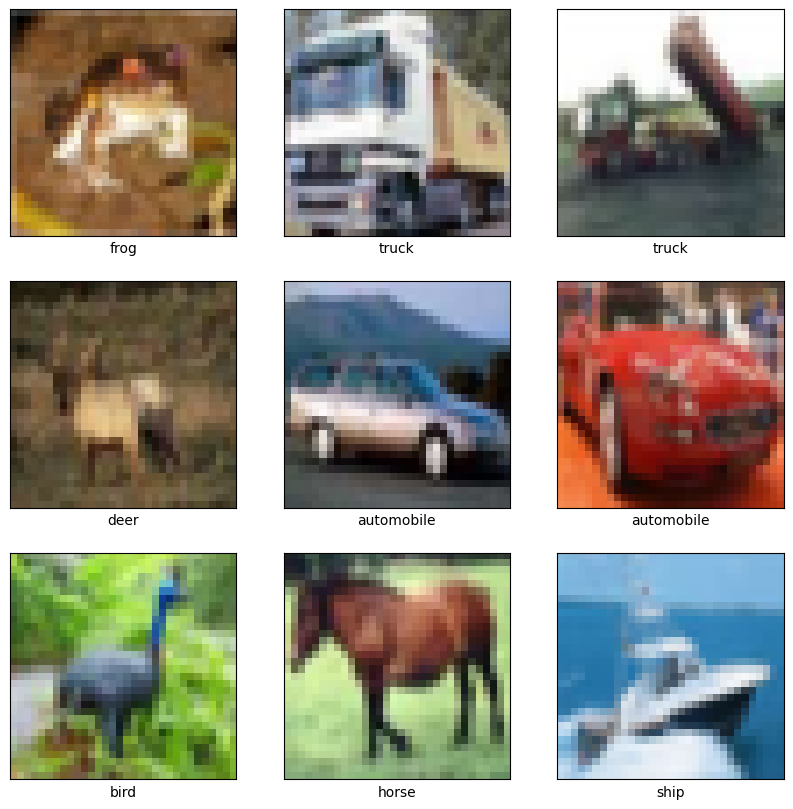

In [5]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.xticks([])
    plt.yticks([])

    plt.imshow(train_images[i])

    plt.xlabel(class_names[train_labels[i][0]])

plt.show()

In [6]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.4379 - loss: 1.5456 - val_accuracy: 0.5497 - val_loss: 1.2697
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.5845 - loss: 1.1720 - val_accuracy: 0.6033 - val_loss: 1.1125
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.6364 - loss: 1.0302 - val_accuracy: 0.6228 - val_loss: 1.0741
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6677 - loss: 0.9408 - val_accuracy: 0.6532 - val_loss: 0.9868
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.6944 - loss: 0.8709 - val_accuracy: 0.6660 - val_loss: 0.9554


In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6660 - loss: 0.9554
Accuracy: 0.6660000085830688


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


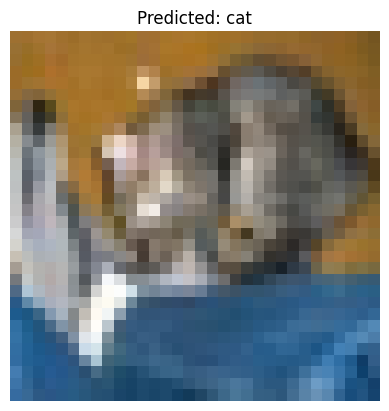

In [10]:
prediction = model.predict(test_images[:1])

predicted_class = class_names[np.argmax(prediction)]

plt.imshow(test_images[0])

plt.title(f"Predicted: {predicted_class}")

plt.axis("off")

plt.show()